# Color & Illumination Normalization (Preprocess)

**ปรับความคงที่ของสีและแสง** เพื่อเตรียมข้อมูลสำหรับเทรนโมเดลความสดของเนื้อวัว

**Pipeline ที่ใช้ (เวอร์ชัน tuned):**
- Soft Gray World White Balance (ปรับสมดุลสีแบบ “ไม่แรงเกิน”)
- CLAHE บนช่อง L (LAB) เพื่อทำ illumination normalization อย่างนุ่มนวล

> เป้าหมาย: ลดผลกระทบจากสภาพแสง/สีที่ต่างกัน แต่ยังคง “สีแดงของเนื้อ” ซึ่งเป็นสัญญาณสำคัญในการจำแนกความสด

## Imports & Setup

In [5]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1) Soft Gray World White Balance (Color Constancy)
**เหตุผลที่ใช้:**  
ภาพจากมือถือ/ตลาดมักติดแสงเหลืองหรือแสงขาว ทำให้สีเนื้อเพี้ยน (color cast) → โมเดลอาจเรียนรู้ “สีของไฟ” แทน “สีของเนื้อ”

**ทำไมต้องเป็น Soft (มี `alpha`):**  
Gray World แบบเต็มอาจทำให้สีเนื้อซีดเกินไป จึงใช้ `alpha` เพื่อลดความแรงของการปรับ

- `alpha = 0.0` → ไม่ปรับ WB  
- `alpha = 1.0` → Gray World เต็ม  
- โปรเจกต์นี้แนะนำช่วง `0.15–0.35` (ปัจจุบันใช้ ~0.25)

In [6]:
def soft_gray_world_white_balance(rgb: np.ndarray, alpha: float = 0.25) -> np.ndarray:
    """
    Soft Gray-World White Balance
    alpha: 0.0 = no WB, 1.0 = full Gray-World
    แนะนำสำหรับเนื้อ: 0.15–0.35
    """
    img = rgb.astype(np.float32)

    mean = img.mean(axis=(0, 1))               # [R, G, B]
    gray_mean = mean.mean()
    full_scale = gray_mean / (mean + 1e-6)     # full gray-world scale

    # soften scaling: 1 + alpha*(scale-1)
    scale = 1.0 + alpha * (full_scale - 1.0)

    out = img * scale
    return np.clip(out, 0, 255).astype(np.uint8)


## 2) Illumination Normalization ด้วย CLAHE (บน LAB: L-channel)

**เหตุผลที่ใช้:**  
ลดความต่างของแสง/เงาในภาพ เช่น แสงสะท้อนหรือแสงไม่สม่ำเสมอ โดยพยายาม “ไม่ทำลายสี” ของเนื้อ

**หลักการ:**  
แปลง RGB → LAB แล้วทำ CLAHE เฉพาะช่อง `L` (ความสว่าง) จากนั้นแปลงกลับเป็น RGB

**พารามิเตอร์หลัก**
- `clip_limit` : ยิ่งสูงยิ่งแรง (เสี่ยงทำให้ภาพดูเป็นฟิลเตอร์)  
- โปรเจกต์นี้ใช้ค่าค่อนข้างอ่อน เพื่อรักษาสี: ประมาณ `1.0–1.2`


In [7]:
def clahe_on_l_channel(rgb: np.ndarray, clip_limit: float = 1.2, tile_grid_size=(8, 8)) -> np.ndarray:
    """
    CLAHE on LAB L-channel to normalize illumination
    แนะนำสำหรับเนื้อ: clip_limit 1.0–1.5
    """
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l2 = clahe.apply(l)

    lab2 = cv2.merge([l2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)


## 3) Preprocess Pipeline (Tuned Version)

รวมขั้นตอนเป็นฟังก์ชันเดียวเพื่อใช้งานง่ายและคงเส้นคงวา

**ข้อสำคัญ (SE/ML):**
- ใช้ pipeline เดียวกันทั้ง **training** และ **inference** เพื่อลดปัญหา *train–serve skew*
- เปิด/ปิดแต่ละขั้นตอนด้วย flag เพื่อเทียบผลได้สะดวก


In [8]:
def preprocess_color_illumination_tuned(
    rgb: np.ndarray,
    use_soft_wb: bool = True,
    wb_alpha: float = 0.25,
    use_clahe: bool = True,
    clahe_clip: float = 1.2
) -> np.ndarray:
    """
    Tuned preprocessing for beef images:
    - Soft white balance (optional)
    - Gentle CLAHE (optional)
    """
    out = rgb
    if use_soft_wb:
        out = soft_gray_world_white_balance(out, alpha=wb_alpha)
    if use_clahe:
        out = clahe_on_l_channel(out, clip_limit=clahe_clip)
    return out


## 4) Single Image Sanity Check (Before vs After)

ทดลองกับ “ภาพเดี่ยว” เพื่อเช็คว่า:
- โค้ดทำงานถูกต้อง
- สีแดงของเนื้อยังดูเป็นธรรมชาติ (ไม่ซีดจนเกินไป)
- illumination สม่ำเสมอขึ้น

> ขั้นตอนนี้ใช้เพื่อ debug และดูผลคร่าว ๆ ก่อนทำการประเมินแบบ batch


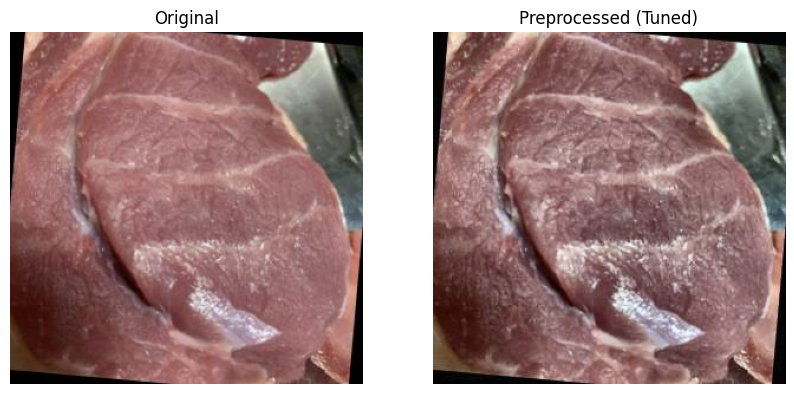

In [9]:
img_path = r"C:\Users\user\Documents\work\medfund\Project_SE_for_AI\datasets\Beef Freshness.v6-dataset-beef-v2.folder\train\Fresh\FRESH-1-_JPG_jpg.rf.35ee26c0fed539cb36e5d2f523856381.jpg"

bgr = cv2.imread(img_path)
if bgr is None:
    raise FileNotFoundError(img_path)

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

rgb_prep = preprocess_color_illumination_tuned(
    rgb,
    use_soft_wb=True,
    wb_alpha=0.25,     # ลอง 0.15, 0.25, 0.35
    use_clahe=True,
    clahe_clip=1.2     # ลอง 1.0, 1.2, 1.4
)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(rgb);      axs[0].set_title("Original")
axs[1].imshow(rgb_prep); axs[1].set_title("Preprocessed (Tuned)")
for ax in axs: ax.axis("off")
plt.show()


## 5) Quantitative Check: R-channel Histogram (Before vs After)

เพราะงานนี้ “สีแดง” เป็นสัญญาณหลักของความสด เราจึงวัดผลด้วยเชิงตัวเลข โดยดูการกระจายของค่า R-channel

สิ่งที่ดู:
- Histogram ก่อน–หลัง ว่า shape เปลี่ยนผิดปกติไหม  
- สถิติ `R_mean / R_std / percentiles` เพื่อเช็คว่า preprocess แรงเกินหรือไม่


In [10]:
def r_channel_hist_and_stats(rgb: np.ndarray, bins: int = 256):
    R = rgb[:, :, 0].astype(np.uint8)

    hist = cv2.calcHist([R], [0], None, [bins], [0, 256]).flatten()
    hist = hist / (hist.sum() + 1e-9)  # normalize to probability

    stats = {
        "R_mean": float(R.mean()),
        "R_std":  float(R.std()),
        "R_min":  int(R.min()),
        "R_max":  int(R.max()),
        "R_p5":   float(np.percentile(R, 5)),
        "R_p50":  float(np.percentile(R, 50)),
        "R_p95":  float(np.percentile(R, 95)),
    }
    return hist, stats


=== R-channel stats (Before) ===
R_mean: 141.68
R_std: 46.10
R_min: 0
R_max: 255
R_p5: 40.00
R_p50: 154.00
R_p95: 196.00

=== R-channel stats (After) ===
R_mean: 135.14
R_std: 46.70
R_min: 0
R_max: 255
R_p5: 46.00
R_p50: 141.00
R_p95: 204.00


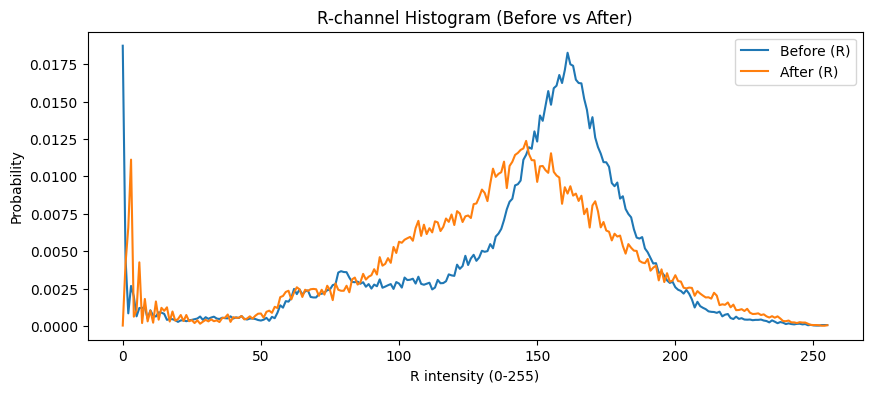

In [11]:
hist_before, stats_before = r_channel_hist_and_stats(rgb)
hist_after,  stats_after  = r_channel_hist_and_stats(rgb_prep)

# Print numeric stats
print("=== R-channel stats (Before) ===")
for k, v in stats_before.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

print("\n=== R-channel stats (After) ===")
for k, v in stats_after.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

# Plot hist
x = np.arange(256)
plt.figure(figsize=(10,4))
plt.plot(x, hist_before, label="Before (R)")
plt.plot(x, hist_after,  label="After (R)")
plt.title("R-channel Histogram (Before vs After)")
plt.xlabel("R intensity (0-255)")
plt.ylabel("Probability")
plt.legend()
plt.show()


In [12]:
# heuristic check: ถ้า median (p50) ของ R ลดลงเยอะมาก แปลว่าแดงโดนกด
drop = stats_before["R_p50"] - stats_after["R_p50"]
print(f"R median drop (before - after) = {drop:.2f}")

if drop > 15:
    print("⚠️ Warning: R-channel median dropped a lot -> อาจซีดเกินไป (ลด wb_alpha หรือปิด WB)")
else:
    print("✅ Looks OK: R-channel preserved reasonably")


R median drop (before - after) = 13.00
✅ Looks OK: R-channel preserved reasonably


In [13]:
def r_median(rgb: np.ndarray) -> float:
    R = rgb[:, :, 0].astype(np.uint8)
    return float(np.percentile(R, 50))

def read_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path))
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


## 6) Batch Evaluation on Training Set (train/)

ทดสอบ preprocessing กับทั้งโฟลเดอร์ `train/` เพื่อยืนยันว่า “เสถียรกับทั้ง dataset” ไม่ใช่ดีเฉพาะบางรูป

สิ่งที่ทำ:
- วนอ่านภาพทุกคลาส (`Fresh`, `Half-Fresh`, `Spoiled`)
- คำนวณ `R median drop` ของแต่ละภาพ
- สรุปสถิติต่อคลาสและรวมทั้งหมด (mean/median/p95 และ % ที่ drop สูงเกิน threshold)



In [14]:
# แก้ path นี้ให้ตรง dataset ที่โฟลเดอร์ train
TRAIN_DIR = Path(r"C:\Users\user\Documents\work\medfund\Project_SE_for_AI\datasets\Beef Freshness.v6-dataset-beef-v2.folder\train")

# ปรับพารามิเตอร์ preprocess ที่คุณต้องการล็อก
WB_ALPHA = 0.25
CLAHE_CLIP = 1.2

# รองรับนามสกุลรูปทั่วไป
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

rows = []
errors = []

for class_dir in sorted([p for p in TRAIN_DIR.iterdir() if p.is_dir()]):
    label = class_dir.name
    img_paths = [p for p in class_dir.rglob("*") if p.suffix.lower() in EXTS]

    for p in img_paths:
        try:
            rgb = read_rgb(p)
            before = r_median(rgb)

            rgb_prep = preprocess_color_illumination_tuned(
                rgb,
                use_soft_wb=True,
                wb_alpha=WB_ALPHA,
                use_clahe=True,
                clahe_clip=CLAHE_CLIP
            )
            after = r_median(rgb_prep)

            drop = before - after  # + = R ลดลง (ซีดลง), - = R เพิ่มขึ้น
            rows.append({
                "path": str(p),
                "class": label,
                "R_p50_before": before,
                "R_p50_after": after,
                "R_p50_drop": drop
            })
        except Exception as e:
            errors.append({"path": str(p), "class": label, "error": str(e)})

df = pd.DataFrame(rows)
df_err = pd.DataFrame(errors)

print("Images processed:", len(df))
print("Errors:", len(df_err))
df.head()


Images processed: 3172
Errors: 0


,path,class,R_p50_before,R_p50_after,R_p50_drop
0,C:\Users\user\Documents\work\medfund\Project_S...,Fresh,154.0,141.0,13.0
1,C:\Users\user\Documents\work\medfund\Project_S...,Fresh,154.0,139.0,15.0
2,C:\Users\user\Documents\work\medfund\Project_S...,Fresh,156.0,141.0,15.0
3,C:\Users\user\Documents\work\medfund\Project_S...,Fresh,155.0,141.0,14.0
4,C:\Users\user\Documents\work\medfund\Project_S...,Fresh,140.0,134.0,6.0


### 6.1 Summary Table (Per Class + Overall)

สรุปสถิติสำคัญ:
- `mean_drop`, `median_drop` → ภาพรวมว่าปรับแรงแค่ไหน  
- `p95_drop` → ขนาดของ outliers ในระดับ 95%  
- `%drop>15`, `%drop>20` → สัดส่วนภาพที่เสี่ยงสีซีด



In [15]:
def summarize(group: pd.Series):
    return pd.Series({
        "n": group.count(),
        "mean_drop": group.mean(),
        "median_drop": group.median(),
        "p95_drop": group.quantile(0.95),
        "pct_drop_gt15": (group > 15).mean() * 100,
        "pct_drop_gt20": (group > 20).mean() * 100
    })

summary_by_class = df.groupby("class")["R_p50_drop"].apply(summarize).reset_index()
summary_all = summarize(df["R_p50_drop"]).to_frame().T
summary_all.insert(0, "class", "ALL")

summary = pd.concat([summary_by_class, summary_all], ignore_index=True)
summary


,class,level_1,R_p50_drop,n,mean_drop,median_drop,p95_drop,pct_drop_gt15,pct_drop_gt20
0,Fresh,n,1208.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,Fresh,mean_drop,8.380795,NaN,NaN,NaN,NaN,NaN,NaN
2,Fresh,median_drop,9.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,Fresh,p95_drop,15.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,Fresh,pct_drop_gt15,3.559603,NaN,NaN,NaN,NaN,NaN,NaN
5,Fresh,pct_drop_gt20,0.082781,NaN,NaN,NaN,NaN,NaN,NaN
6,Half-Fresh,n,1100.000000,NaN,NaN,NaN,NaN,NaN,NaN
7,Half-Fresh,mean_drop,6.400909,NaN,NaN,NaN,NaN,NaN,NaN
8,Half-Fresh,median_drop,6.000000,NaN,NaN,NaN,NaN,NaN,NaN
9,Half-Fresh,p95_drop,13.000000,NaN,NaN,NaN,NaN,NaN,NaN


### 6.2 Distribution Plot

แสดง distribution ของ `R median drop` แยกตามคลาสเพื่อดูว่า:
- preprocess bias ต่อบางคลาสหรือไม่
- tail ของ outliers อยู่มากน้อยแค่ไหน


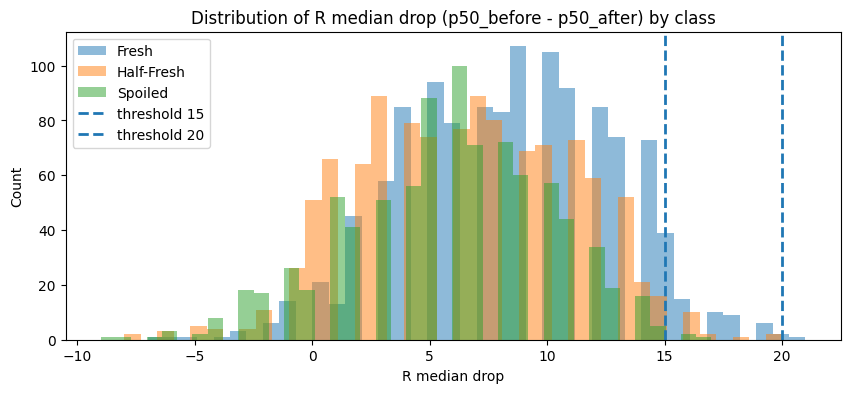

In [16]:
plt.figure(figsize=(10,4))
for cls, g in df.groupby("class"):
    plt.hist(g["R_p50_drop"], bins=40, alpha=0.5, label=cls)

plt.axvline(15, linestyle="--", linewidth=2, label="threshold 15")
plt.axvline(20, linestyle="--", linewidth=2, label="threshold 20")
plt.title("Distribution of R median drop (p50_before - p50_after) by class")
plt.xlabel("R median drop")
plt.ylabel("Count")
plt.legend()
plt.show()


### 6.3 Inspect Outliers (Worst Cases)

ดึงภาพที่ `R median drop` สูงสุด เพื่อดูด้วยตาอีกครั้งว่า:
- เป็นภาพที่แสงเพี้ยน/สะท้อนหนักจริงไหม
- จำเป็นต้องใช้ Quality Gate ในขั้นถัดไปหรือไม่


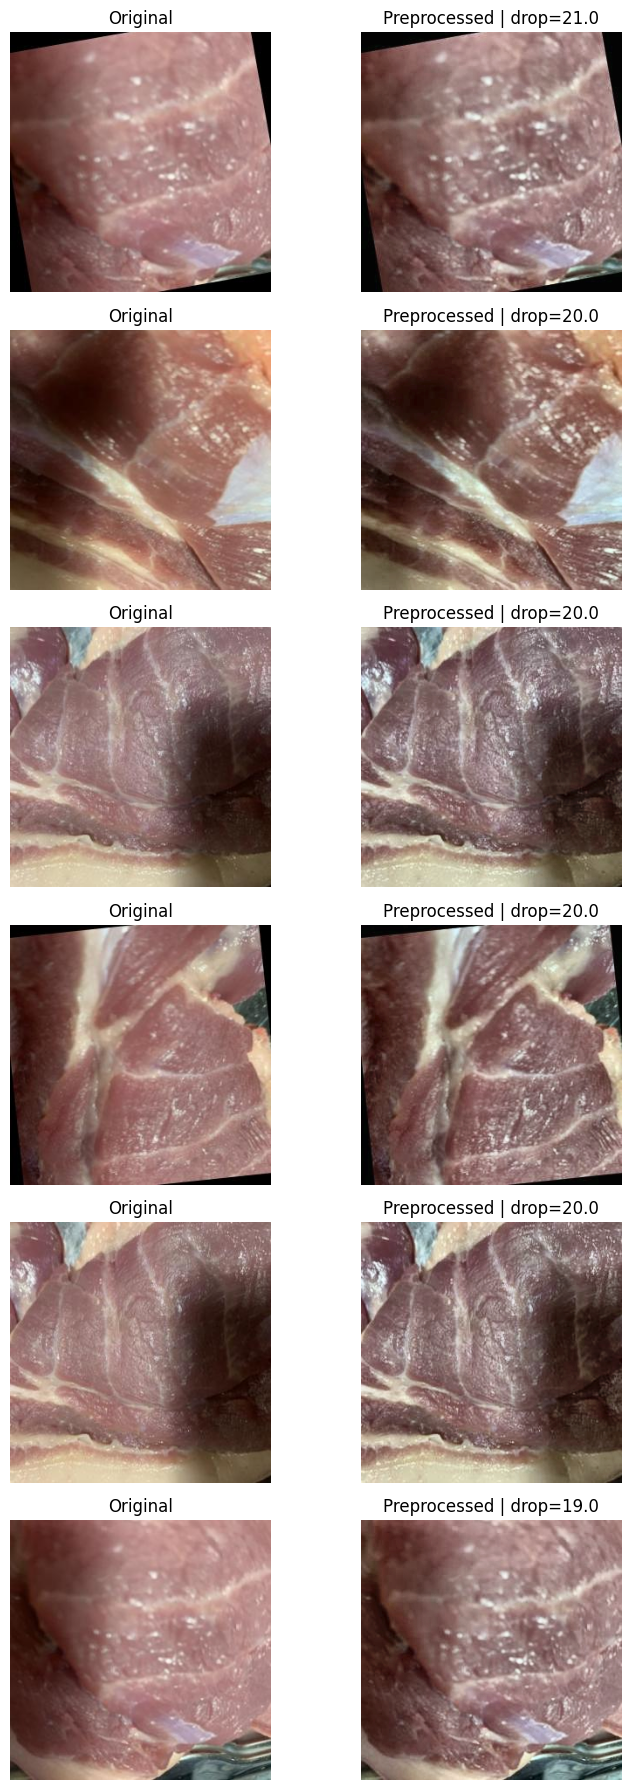

In [17]:
df.sort_values("R_p50_drop", ascending=False).head(10)[["class","R_p50_drop","path"]]
TOP_N = 6
worst_cases = df.sort_values("R_p50_drop", ascending=False).head(TOP_N)

fig, axs = plt.subplots(TOP_N, 2, figsize=(8, 3*TOP_N))

for i, (_, row) in enumerate(worst_cases.iterrows()):
    rgb = read_rgb(Path(row["path"]))
    rgb_prep = preprocess_color_illumination_tuned(
        rgb,
        use_soft_wb=True,
        wb_alpha=WB_ALPHA,
        use_clahe=True,
        clahe_clip=CLAHE_CLIP
    )

    axs[i, 0].imshow(rgb)
    axs[i, 0].set_title("Original")
    axs[i, 1].imshow(rgb_prep)
    axs[i, 1].set_title(f"Preprocessed | drop={row['R_p50_drop']:.1f}")

    axs[i, 0].axis("off")
    axs[i, 1].axis("off")

plt.tight_layout()
plt.show()


## 7) Visual Inspection (Random Samples)

สุ่มแสดงภาพก่อน–หลังจาก dataset เพื่อยืนยันเชิงสายตาว่า:
- preprocess ทำให้ภาพดูเป็นธรรมชาติ
- ความแตกต่างระหว่างระดับความสดยังคงอยู่ (ไม่ทำให้ทุกภาพเหมือนกันหมด)



=== Class: Fresh ===


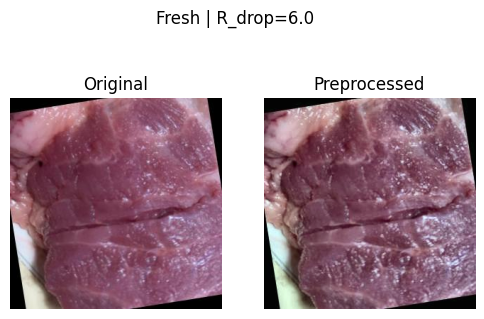

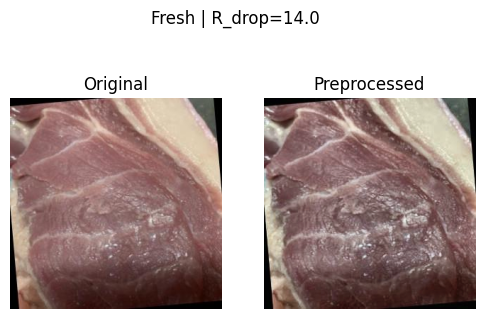


=== Class: Half-Fresh ===


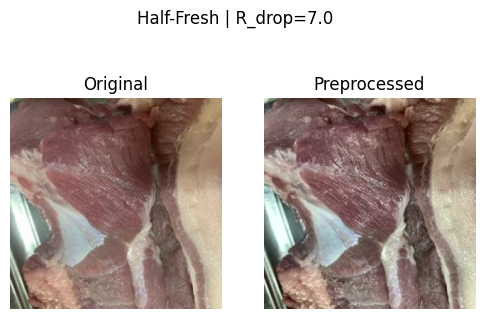

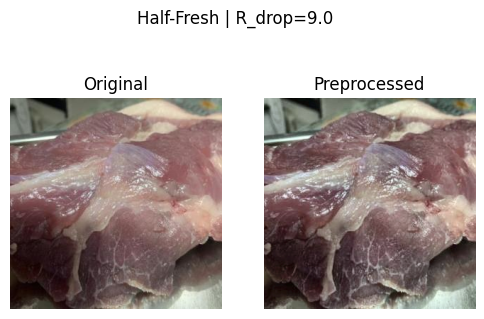


=== Class: Spoiled ===


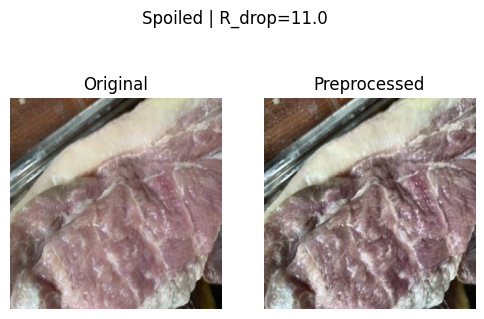

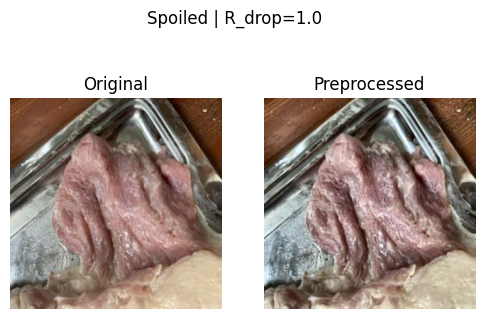

In [18]:
import random
import matplotlib.pyplot as plt

def show_before_after(path, title=""):
    rgb = read_rgb(Path(path))
    rgb_prep = preprocess_color_illumination_tuned(
        rgb,
        use_soft_wb=True,
        wb_alpha=WB_ALPHA,
        use_clahe=True,
        clahe_clip=CLAHE_CLIP
    )

    fig, axs = plt.subplots(1, 2, figsize=(6, 4))
    axs[0].imshow(rgb)
    axs[0].set_title("Original")
    axs[1].imshow(rgb_prep)
    axs[1].set_title("Preprocessed")

    for ax in axs:
        ax.axis("off")
    fig.suptitle(title)
    plt.show()


for cls in df["class"].unique():
    print(f"\n=== Class: {cls} ===")
    sample_cls = df[df["class"] == cls].sample(2, random_state=42)

    for _, row in sample_cls.iterrows():
        show_before_after(
            row["path"],
            title=f"{cls} | R_drop={row['R_p50_drop']:.1f}"
        )



## Conclusion

- Pipeline สำหรับ Color & Illumination Normalization ถูกออกแบบให้ใช้ร่วมกันทั้ง train/inference
- ผ่านการตรวจสอบเชิงสายตา (before/after) และเชิงตัวเลข (R-channel histogram + batch statistics)
